In [277]:
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping

In [133]:
print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [134]:
train_df = pd.read_parquet(
    "../data/train_df.parquet"
)

val_df = pd.read_parquet(
    "../data/val_df.parquet"
)

In [150]:
selected_containers = (
    train_df["container_id"]
    .unique()[:100]
)

In [307]:
selected_containers

<ArrowStringArray>
['c_10032', 'c_10034', 'c_10089', 'c_10132',  'c_1016', 'c_10306', 'c_10312',
 'c_10382', 'c_10393', 'c_10641', 'c_10695', 'c_10733', 'c_10878', 'c_10898',
 'c_11013', 'c_11087', 'c_11203', 'c_11307', 'c_11327', 'c_11461', 'c_11735',
 'c_11752',  'c_1181',  'c_1186', 'c_11996', 'c_12060', 'c_12158', 'c_12164',
 'c_12174', 'c_12189', 'c_12193', 'c_12231', 'c_12237', 'c_12441', 'c_12517',
 'c_12624', 'c_12767', 'c_12858',  'c_1286', 'c_12971', 'c_12974', 'c_12993',
 'c_12999', 'c_13020', 'c_13044', 'c_13083', 'c_13166', 'c_13170', 'c_13229',
 'c_13269', 'c_13308', 'c_13389', 'c_13403', 'c_13441', 'c_13607', 'c_13615',
 'c_13658', 'c_13690',  'c_1379',  'c_1387', 'c_13873', 'c_14106', 'c_14135',
 'c_14296', 'c_14363', 'c_14388', 'c_14396', 'c_14413', 'c_14416', 'c_14417',
 'c_14435', 'c_14471', 'c_14674', 'c_14820', 'c_14855', 'c_14886',  'c_1494',
 'c_14964', 'c_15030', 'c_15035', 'c_15072', 'c_15179', 'c_15235', 'c_15282',
 'c_15420', 'c_15446', 'c_15486', 'c_15527', 

In [308]:
np.save(
    "../data/selected_containers.npy",
    selected_containers
)

In [152]:
global_train = train_df[
    train_df["container_id"].isin(selected_containers)
].copy()

global_val = val_df[
    val_df["container_id"].isin(selected_containers)
].copy()

In [153]:
global_val

,container_id,time_stamp,cpu_util_percent,cpu_usage,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour
0,c_10032,1970-01-08 09:30:00,3.333333,3.333333,3.333333,0.345679,0.224547,0.171215,1.0,0.0,9
1,c_10032,1970-01-08 09:45:00,3.500000,3.500000,3.500000,0.370370,0.224547,0.171215,1.0,0.0,9
2,c_10032,1970-01-08 10:00:00,3.000000,3.000000,3.000000,0.296296,0.224547,0.171215,1.0,0.0,10
3,c_10032,1970-01-08 10:15:00,4.000000,4.000000,4.000000,0.444444,0.224547,0.171215,1.0,0.0,10
4,c_10032,1970-01-08 10:30:00,3.000000,3.000000,3.000000,0.296296,0.224547,0.171215,1.0,0.0,10
...,...,...,...,...,...,...,...,...,...,...,...
15368,c_16048,1970-01-09 22:45:00,20.000000,20.000000,20.000000,0.486486,0.390516,0.245167,1.0,0.0,22
15369,c_16048,1970-01-09 23:00:00,4.000000,4.000000,4.000000,0.054054,0.390516,0.245167,1.0,0.0,23
15370,c_16048,1970-01-09 23:15:00,2.000000,2.000000,2.000000,0.000000,0.390516,0.245167,1.0,0.0,23
15371,c_16048,1970-01-09 23:30:00,4.000000,4.000000,4.000000,0.054054,0.390516,0.245167,1.0,0.0,23


In [154]:
features = [
    "cpu_scaled",
    # "hour",
    "cpu_mean",
    "cpu_std"
]

In [227]:
import numpy as np

def create_longterm_sequences(
    df,
    features,
    target,
    input_window=96,
    forecast_horizon=96
):

    X = []
    y = []

    sample_cids = []

    for cid, group in df.groupby("container_id"):

        group = group.sort_values("time_stamp")

        values = group[features].values
        target_values = group[target].values

        max_idx = (
            len(group)
            - input_window
            - forecast_horizon
        )

        for i in range(max_idx):

            # ---------------- INPUT WINDOW ----------------
            X.append(
                values[
                    i : i + input_window
                ]
            )

            # ---------------- FUTURE TARGET ----------------
            y.append(
                target_values[
                    i + input_window :
                    i + input_window + forecast_horizon
                ]
            )

            # ---------------- STORE CONTAINER ID ----------------
            sample_cids.append(cid)

    return (
        np.array(X),
        np.array(y),
        np.array(sample_cids)
    )

In [228]:
full_df = pd.concat([global_train, global_val])

In [229]:
full_df

,container_id,time_stamp,cpu_util_percent,cpu_usage,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour
0,c_10032,1970-01-02 00:00:00,1.00,1.000,1.000,0.000000,0.224547,0.171215,1.0,0.0,0
1,c_10032,1970-01-02 00:15:00,2.00,2.000,2.000,0.148148,0.224547,0.171215,1.0,0.0,0
2,c_10032,1970-01-02 00:30:00,NaN,1.625,1.625,0.092593,0.224547,0.171215,1.0,0.0,0
3,c_10032,1970-01-02 00:45:00,1.25,1.250,1.250,0.037037,0.224547,0.171215,1.0,0.0,0
4,c_10032,1970-01-02 01:00:00,1.00,1.000,1.000,0.000000,0.224547,0.171215,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
15368,c_16048,1970-01-09 22:45:00,20.00,20.000,20.000,0.486486,0.390516,0.245167,1.0,0.0,22
15369,c_16048,1970-01-09 23:00:00,4.00,4.000,4.000,0.054054,0.390516,0.245167,1.0,0.0,23
15370,c_16048,1970-01-09 23:15:00,2.00,2.000,2.000,0.000000,0.390516,0.245167,1.0,0.0,23
15371,c_16048,1970-01-09 23:30:00,4.00,4.000,4.000,0.054054,0.390516,0.245167,1.0,0.0,23


In [230]:
X_all, y_all, cids_all = create_longterm_sequences(
    full_df,
    features=features,
    target="cpu_scaled",
    input_window=96,
    forecast_horizon=96
)

In [231]:
print(X_all.shape)
print(y_all.shape)
print(cids_all.shape)

(57445, 96, 3)
(57445, 96)
(57445,)


In [232]:
split_idx = int(len(X_all) * 0.8)

X_train = X_all[:split_idx]
y_train = y_all[:split_idx]

X_val = X_all[split_idx:]
y_val = y_all[split_idx:]

train_cids = cids_all[:split_idx]
val_cids = cids_all[split_idx:]

In [233]:
# X_val, y_val = create_longterm_sequences(
#     global_val,
#     features=features,
#     target="cpu_scaled",
#     input_window=96,
#     forecast_horizon=96
# )

In [234]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

(45956, 96, 3)
(45956, 96)
(11489, 96, 3)
(11489, 96)


In [235]:
# X_train = np.load("../data/X_train.npy")
# y_train = np.load("../data/y_train.npy")

# X_val = np.load("../data/X_val.npy")
# y_val = np.load("../data/y_val.npy")

In [236]:
with open("../data/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

/Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [279]:
global_model = Sequential([
    GRU(
        128,
        return_sequences=True,
        input_shape=(96, len(features))
    ),
    Dropout(0.2),
    GRU(64),
    Dense(64, activation="relu"),
    Dense(96)
])

In [280]:
global_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [281]:
global_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 96, 128)        │        51,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,720 (385.62 KB)

 Trainable params: 98,720 (385.62 KB)

 Non-trainable params: 0 (0.00 B)

In [282]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [284]:
history = global_model.fit(
    X_train,
    y_train,
    # validation_split=0.1,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    shuffle=False,
    callbacks=[early_stop]
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.0373 - mae: 0.1342 - val_loss: 0.0388 - val_mae: 0.1369
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0274 - mae: 0.1140 - val_loss: 0.0385 - val_mae: 0.1329
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0265 - mae: 0.1111 - val_loss: 0.0354 - val_mae: 0.1260
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0234 - mae: 0.1042 - val_loss: 0.0371 - val_mae: 0.1303
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0230 - mae: 0.1030 - val_loss: 0.0362 - val_mae: 0.1275
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0227 - mae: 0.1021 - val_loss: 0.0349 - val_mae: 0.1232
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0224 - mae: 0.1016 - val_loss: 0.0346 - val_mae: 0.1223
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0213 - mae: 0.0986 - val_loss: 0.0340 - val_mae: 0.1189
Epoch 9/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/

In [285]:
y_pred = global_model.predict(X_val)

360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [286]:
y_pred.shape

(11489, 96)

In [287]:
print(y_pred.shape)
print(y_val.shape)

(11489, 96)
(11489, 96)


In [297]:
sample_idx = 0

In [298]:
cid = val_cids[sample_idx]
print(cid)

c_15035


In [299]:
scaler = scalers[cid]

In [300]:
pred_scaled = y_pred[sample_idx]
actual_scaled = y_val[sample_idx]

In [301]:
# scaler = list(scalers.values())[0]

In [302]:
pred_real = scaler.inverse_transform(
    pred_scaled.reshape(-1,1)
)

actual_real = scaler.inverse_transform(
    actual_scaled.reshape(-1,1)
)

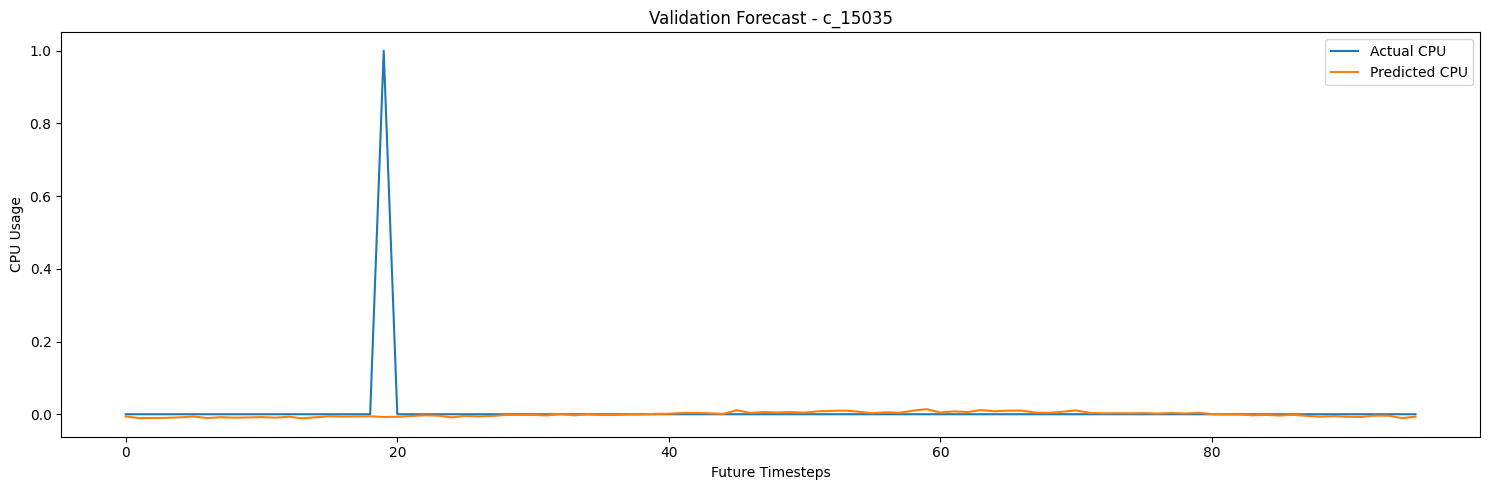

In [303]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    actual_real,
    label="Actual CPU"
)

plt.plot(
    pred_real,
    label="Predicted CPU"
)

plt.title(
    f"Validation Forecast - {cid}"
)

plt.xlabel("Future Timesteps")
plt.ylabel("CPU Usage")

plt.legend()

plt.tight_layout()

plt.show()

In [304]:
mae = mean_absolute_error(
    actual_real,
    pred_real
)

print("MAE:", mae)

MAE: 0.015863296820801526


In [296]:
rmse = np.sqrt(
    mean_squared_error(
        actual_real,
        pred_real
    )
)

print("RMSE:", rmse)

RMSE: 1.944879130049835


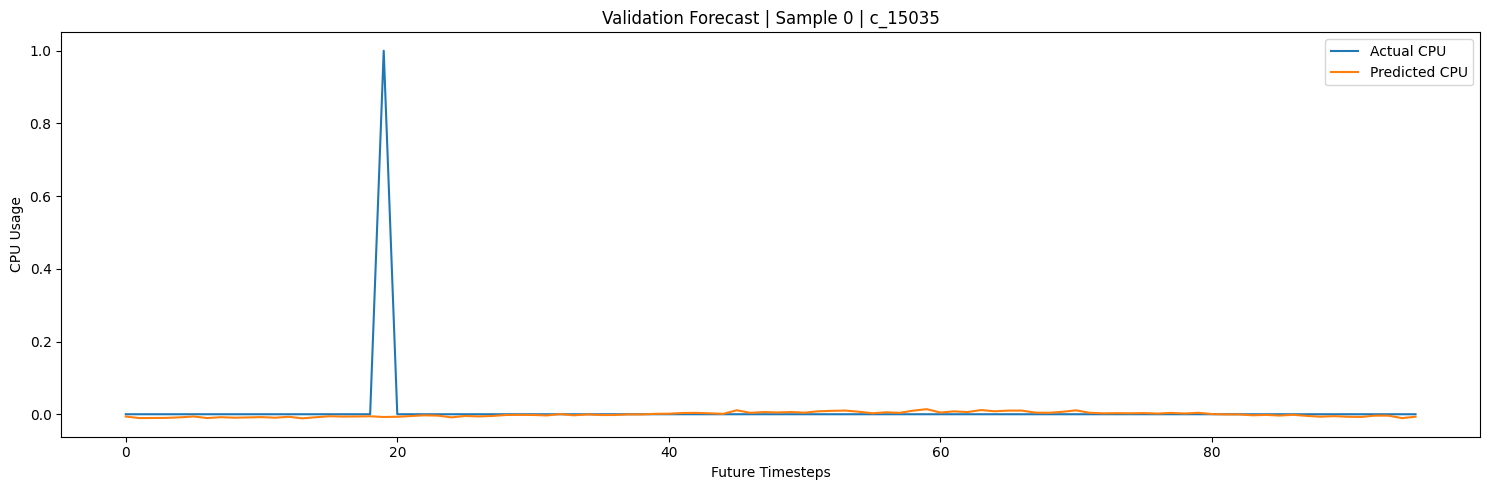

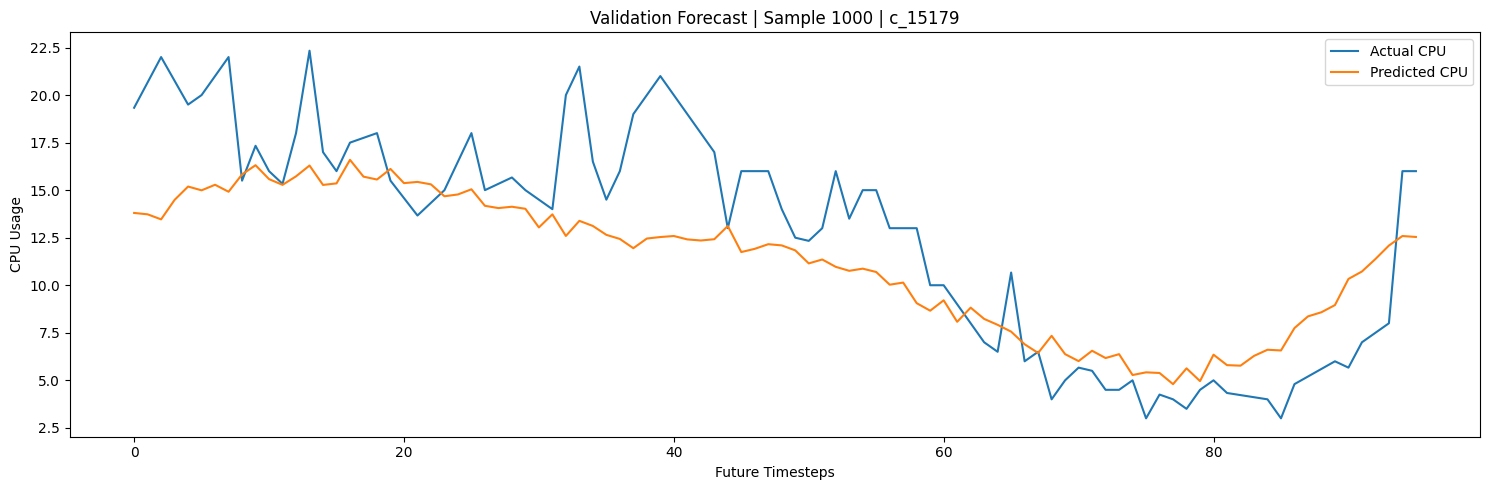

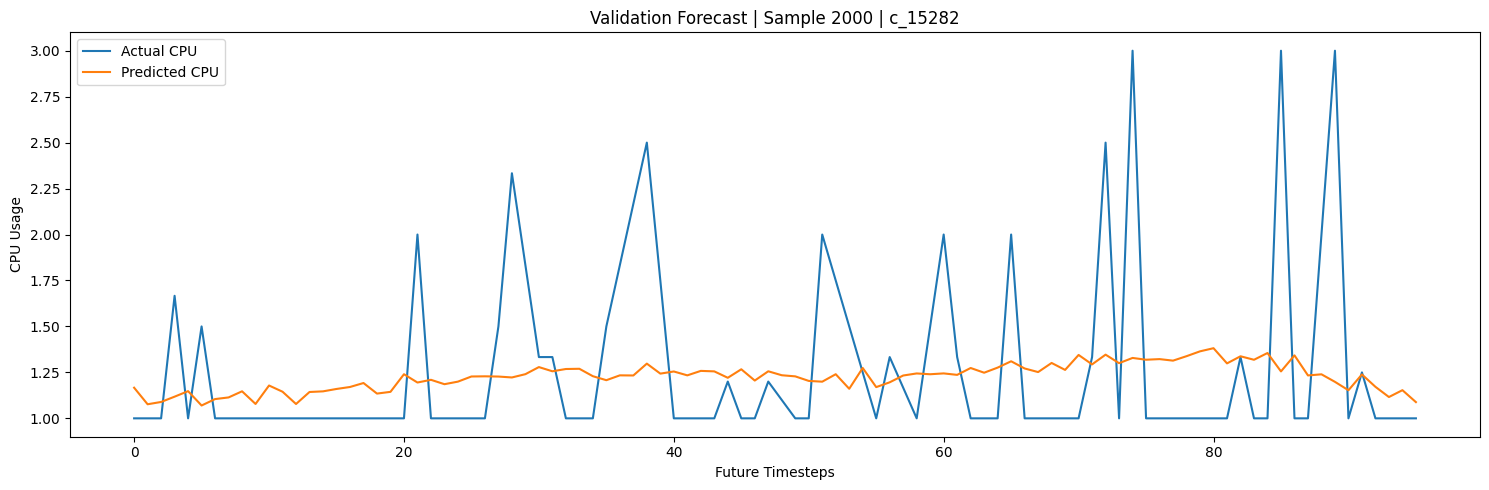

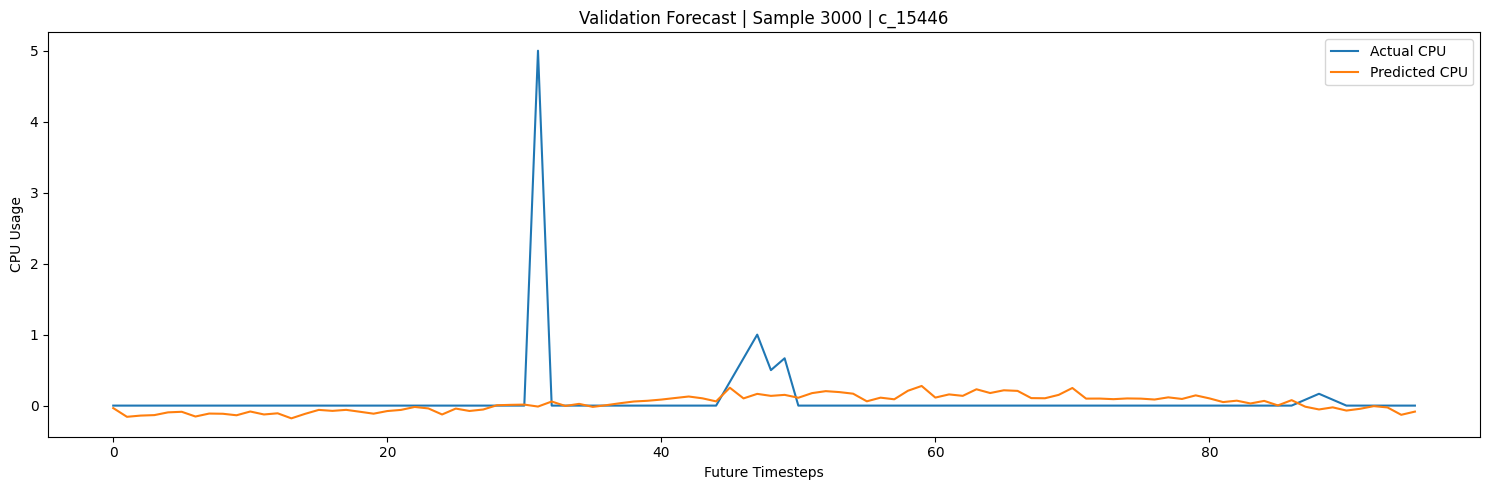

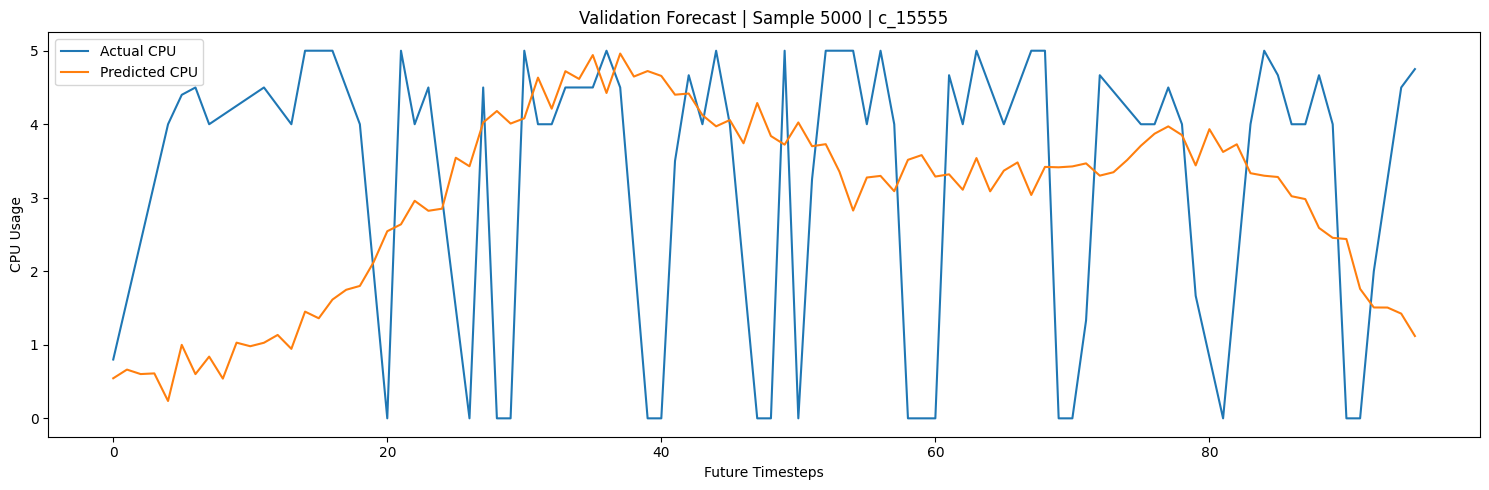

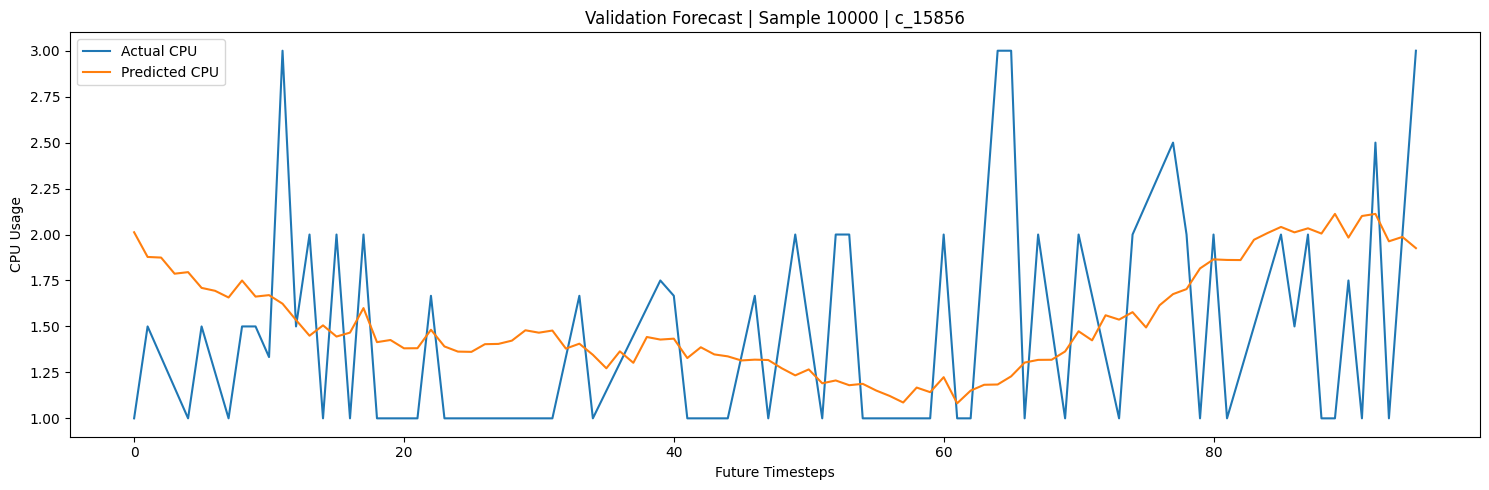

In [306]:
sample_indices = [0, 1000, 2000, 3000, 5000, 10000]

for sample_idx in sample_indices:

    # ---------------- CONTAINER ----------------
    cid = val_cids[sample_idx]

    scaler = scalers[cid]

    # ---------------- DATA ----------------
    pred_scaled = y_pred[sample_idx]
    actual_scaled = y_val[sample_idx]

    # ---------------- INVERSE TRANSFORM ----------------
    pred_real = scaler.inverse_transform(
        pred_scaled.reshape(-1,1)
    )

    actual_real = scaler.inverse_transform(
        actual_scaled.reshape(-1,1)
    )

    # ---------------- PLOT ----------------
    plt.figure(figsize=(15,5))

    plt.plot(
        actual_real,
        label="Actual CPU"
    )

    plt.plot(
        pred_real,
        label="Predicted CPU"
    )

    plt.title(
        f"Validation Forecast | Sample {sample_idx} | {cid}"
    )

    plt.xlabel("Future Timesteps")
    plt.ylabel("CPU Usage")

    plt.legend()

    plt.tight_layout()

    plt.show()

Plot for selected container

In [320]:
target_cid = "c_11307"

In [321]:
container_df = full_df[
    full_df["container_id"] == target_cid
].sort_values("time_stamp")

In [322]:
X_test, y_test, cids_test = (
    create_longterm_sequences(
        container_df,
        features=features,
        target="cpu_scaled",
        input_window=96,
        forecast_horizon=96
    )
)

In [323]:
y_pred = global_model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [324]:
sample_idx = 100

In [325]:
scaler = scalers[target_cid]

pred_real = scaler.inverse_transform(
    y_pred[sample_idx].reshape(-1,1)
)

actual_real = scaler.inverse_transform(
    y_test[sample_idx].reshape(-1,1)
)

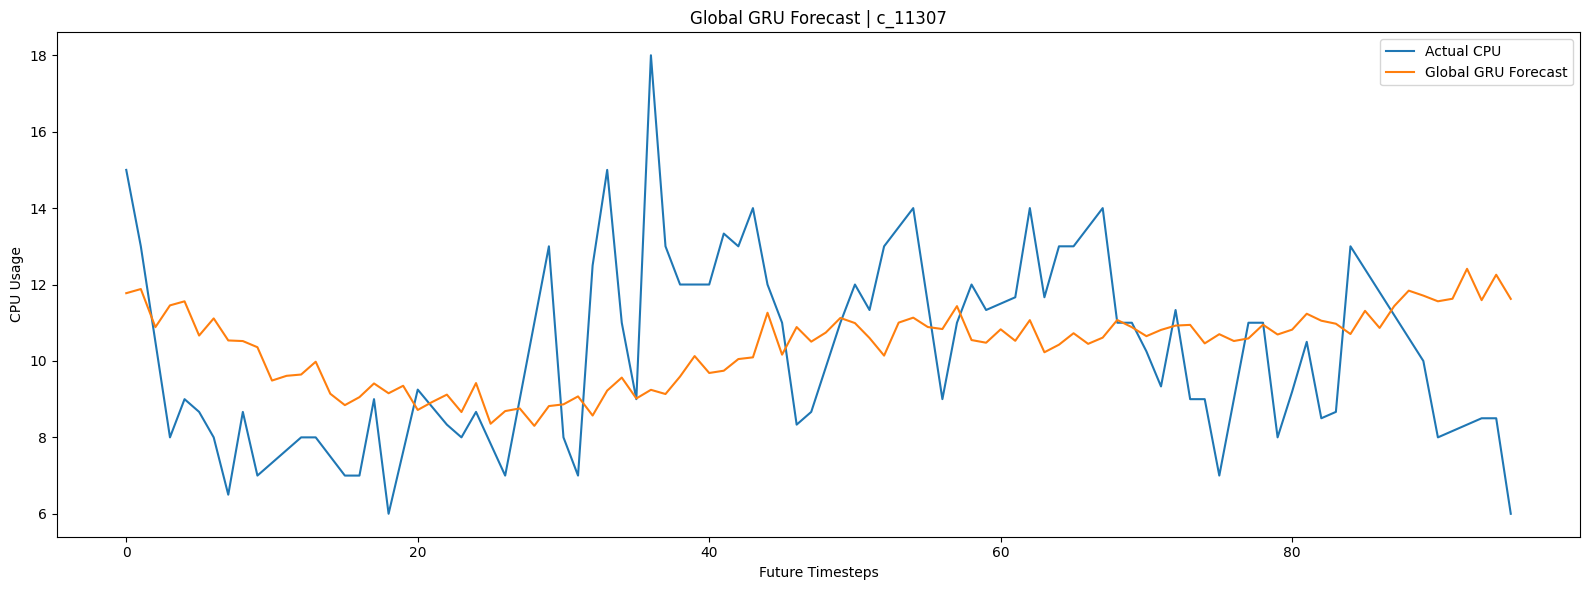

In [326]:
plt.figure(figsize=(16,6))

plt.plot(
    actual_real,
    label="Actual CPU"
)

plt.plot(
    pred_real,
    label="Global GRU Forecast"
)

plt.title(
    f"Global GRU Forecast | {target_cid}"
)

plt.xlabel("Future Timesteps")
plt.ylabel("CPU Usage")

plt.legend()

plt.tight_layout()

plt.show()

In [329]:
hybrid_mae = mean_absolute_error(
    actual_real,
    pred_real
)

hybrid_rmse = np.sqrt(
    mean_squared_error(
        actual_real,
        pred_real
    )
)

print("MAE :", hybrid_mae)
print("RMSE:", hybrid_rmse)

MAE : 1.9978706459204358
RMSE: 2.469825071242139
